# Uber Ride Bookings — Exploratory Data Analysis
**Dataset:** NCR Ride Bookings | **Tools:** Python, Pandas, Matplotlib, Seaborn, Plotly

#### Import Neccessary Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

#### Load the Data

In [3]:
# Load the dataset
df = pd.read_csv("ncr_ride_bookings.csv")

In [4]:
print(f'Dataset Shape: {df.shape}')
print(f'Total Rides: {len(df)}')

# Quick summary of data
print(f'\n Column Info:')
print(f'Total Column: {len(df.columns)}')

df.info()

Dataset Shape: (150000, 21)
Total Rides: 150000

 Column Info:
Total Column: 21
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        

In [5]:
# check out the first five rows
print('First look at our data:')
print(df.head())

print(f'\nDate range: {df['Date'].min()} to {df['Date'].max()}')
print(f'Vehicle Type: {df['Vehicle Type'].nunique()}')
print(f'Unique customers: {df['Customer ID'].nunique():,}')

# Stats on booking status
print(f'\nBooking Status Distribution:')
print(df['Booking Status'].value_counts())

First look at our data:
         Date      Time    Booking ID   Booking Status   Customer ID  \
0  2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1  2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2  2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3  2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4  2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   

    Vehicle Type      Pickup Location      Drop Location  Avg VTAT  Avg CTAT  \
0          eBike          Palam Vihar            Jhilmil       NaN       NaN   
1       Go Sedan        Shastri Nagar  Gurgaon Sector 56       4.9      14.0   
2           Auto              Khandsa      Malviya Nagar      13.4      25.8   
3  Premier Sedan  Central Secretariat           Inderlok      13.1      28.5   
4           Bike     Ghitorni Village        Khan Market       5.3      19.6   

   ...  Reason for cancelling by Customer Cancelled Rides by D

#### Clean the Data

In [6]:
def clean_data(df):
    """Clean and Prepare our data for analysis"""

    # Make a copy of data to avoid the modifications in original data
    df_clean = df.copy()

    # Convert Dates and Time
    df_clean['Date'] = pd.to_datetime(df_clean['Date'])
    df_clean['DateTime'] = pd.to_datetime(df_clean['Date'].astype(str) + ' ' + df_clean['Time'].astype(str))  

    # Time features
    df_clean['Hour'] = df_clean['DateTime'].dt.hour
    df_clean['DayofWeek'] = df_clean['DateTime'].dt.day_name()
    df_clean['Month'] = df_clean['DateTime'].dt.month
    df_clean['Weekends'] = df_clean['DateTime'].dt.weekday >= 5

    # Clean numeric columns
    cols = ['Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']

    for col in cols:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    # Create useful flags
    df_clean['Is_Successful'] = df_clean['Booking Status'] == 'Completed'
    df_clean['Is_Cancelled_Customer'] = df_clean['Cancelled Rides by Customer'].notna()
    df_clean['Is_Cancelled_Driver'] = df_clean['Cancelled Rides by Driver'].notna()

    # Categorize status
    def Categorize_status(status):
        if status == 'Completed':
            return 'Completed'
        elif 'Cancelled' in str(status):
            return 'Cancelled'
        elif status == 'No Driver Found':
            return 'No Driver Found'
        else:
            return 'Other'

    df_clean['Status Category'] = df_clean['Booking Status'].apply(Categorize_status)

    return df_clean

# Clean our data
df = clean_data(df)
print(f'\n👍Data Cleaning Completed')
print(f'📝Ready for analysis with {len(df)} rides')


👍Data Cleaning Completed
📝Ready for analysis with 150000 rides


### Exuctive Overview

In [7]:
def key_metrics(df):
    total_rides = len(df)
    completed_rides = df['Is_Successful'].sum()
    completion_rate = (completed_rides/total_rides)*100

    total_revenue = df[df['Is_Successful']]['Booking Value'].sum()
    avg_booking_value = df[df['Is_Successful']]['Booking Value'].mean()

    avg_ride_distance = df[df['Is_Successful']]['Ride Distance'].mean()
    avg_driver_rating = df[df['Is_Successful']]['Driver Ratings'].mean()
    avg_customer_rating = df[df['Is_Successful']]['Customer Rating'].mean()

    # Cancellation Analysis
    customer_cancellations = df['Is_Cancelled_Customer'].sum()
    driver_cancellations = df['Is_Cancelled_Driver'].sum()

    return {
        'total_rides': total_rides,
        'completed_rides': completed_rides,
        'completion_rate': completion_rate,
        'total_revenue': total_revenue,
        'avg_booking_value': avg_booking_value,
        'avg_ride_distance': avg_ride_distance,
        'avg_driver_rating': avg_driver_rating,
        'avg_customer_rating': avg_customer_rating,
        'customer_cancellations': customer_cancellations,
        'driver_cancellations': driver_cancellations
    }

# Get our key metrics
metrics = key_metrics(df)

print("🎯 KEY METRICS")
print("=" * 50)
print(f"📊 Total Rides Analyzed: {metrics['total_rides']:,}")
print(f"✅ Completed Rides: {metrics['completed_rides']:,}")
print(f"📈 Completion Rate: {metrics['completion_rate']:.1f}%")
print(f"💰 Total Revenue: ₹{metrics['total_revenue']:,.0f}")
print(f"💵 Average Booking Value: ₹{metrics['avg_booking_value']:.0f}")
print(f"🛣️ Average Distance: {metrics['avg_ride_distance']:.1f} km")
print(f"⭐ Avg Driver Rating: {metrics['avg_driver_rating']:.2f}/5")
print(f"⭐ Avg Customer Rating: {metrics['avg_customer_rating']:.2f}/5")
print(f"❌ Customer Cancellations: {metrics['customer_cancellations']:,}")
print(f"🚫 Driver Cancellations: {metrics['driver_cancellations']:,}")
print("=" * 50)

🎯 KEY METRICS
📊 Total Rides Analyzed: 150,000
✅ Completed Rides: 93,000
📈 Completion Rate: 62.0%
💰 Total Revenue: ₹47,260,574
💵 Average Booking Value: ₹508
🛣️ Average Distance: 26.0 km
⭐ Avg Driver Rating: 4.23/5
⭐ Avg Customer Rating: 4.40/5
❌ Customer Cancellations: 10,500
🚫 Driver Cancellations: 27,000


### Demand Analysis

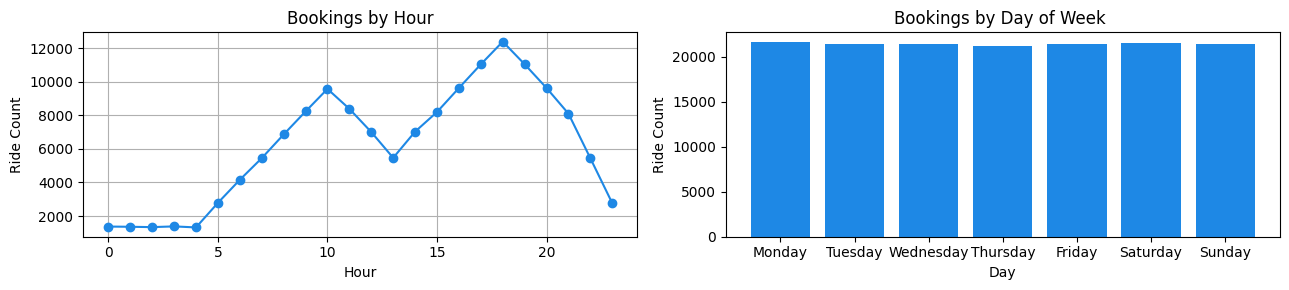

In [8]:
# plot a graph that will tells about peak hours
plt.figure(figsize=(13,3))

plt.subplot(1,2,1)
df.groupby('Hour').size().plot(kind='line', color='#1E88E5', marker = 'o',)
plt.title('Bookings by Hour')
plt.grid(True)
plt.ylabel('Ride Count')
plt.tight_layout()

# Plot a graph for day wise trend
plt.subplot(1,2,2)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ride_count = df['DayofWeek'].value_counts()
ride_count = ride_count.reindex(day_order)

plt.bar(ride_count.index, ride_count.values, color='#1E88E5')
plt.title('Bookings by Day of Week ')
plt.xlabel('Day')
plt.ylabel('Ride Count')
plt.tight_layout()
plt.show()

In [9]:
ride_pivot = df.pivot_table(index='DayofWeek', values='Booking ID', columns='Hour', aggfunc= 'count', fill_value=0)

# Reorder columns so days appear in chronological order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Match the exact casing/naming style present in 'DayofWeek' column
ride_pivot = ride_pivot.reindex(days_order)
ride_pivot

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
DayofWeek,,,,,,,,,,,,,,,,,,,,,
Monday,204,209,206,203,183,446,594,770,1026,1204,...,1006,1166,1394,1578,1835,1564,1418,1215,728,409
Tuesday,179,186,206,206,185,418,626,795,1026,1141,...,1003,1198,1329,1539,1763,1596,1372,1166,798,381
Wednesday,208,188,195,180,185,369,621,775,942,1214,...,963,1170,1394,1606,1789,1565,1412,1109,791,428
Thursday,207,197,186,197,170,396,575,774,937,1148,...,987,1227,1357,1583,1687,1547,1364,1142,783,390
Friday,180,187,190,203,204,379,585,766,984,1168,...,1043,1156,1409,1542,1767,1576,1371,1107,762,362
Saturday,195,201,174,190,201,412,593,776,965,1158,...,1036,1168,1356,1604,1800,1559,1380,1171,789,422
Sunday,200,192,182,204,193,366,566,794,981,1201,...,993,1117,1394,1592,1756,1640,1313,1193,790,370


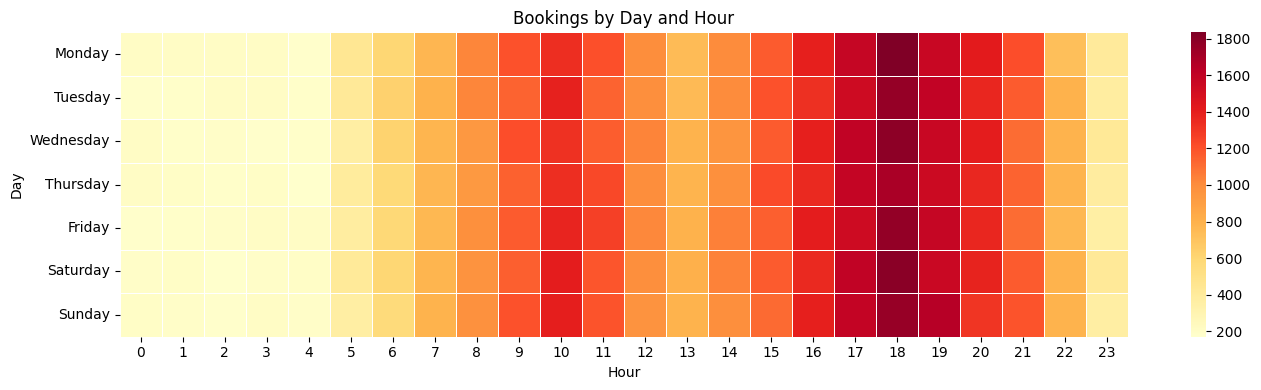

In [10]:
plt.figure(figsize=(14,4))

sns.heatmap(
    ride_pivot,
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    annot=False
)

plt.title("Bookings by Day and Hour")
plt.xlabel("Hour")
plt.ylabel("Day")
plt.tight_layout()
plt.show()

#### Insights
1. Ride demand is lowest during the early morning hours (12 AM–4 AM), indicating minimal customer activity overnight.
2. Booking volume starts increasing from 5 AM and continues to rise throughout the morning.
3. A morning peak is observed around 10 AM, suggesting increased demand during office commuting hours.
4. Ride bookings increase again from 3 PM to 8 PM, representing the busiest period of the day.
5. The highest number of bookings occurs at 6 PM, indicating the evening rush hour is the peak demand period.
6. Booking volumes gradually decline after 8 PM.
7. Booking demand is fairly consistent across all days of the week, with no significant difference between weekdays and weekends.
8. The heatmap confirms that 5 PM–7 PM is consistently the busiest time across all seven days.

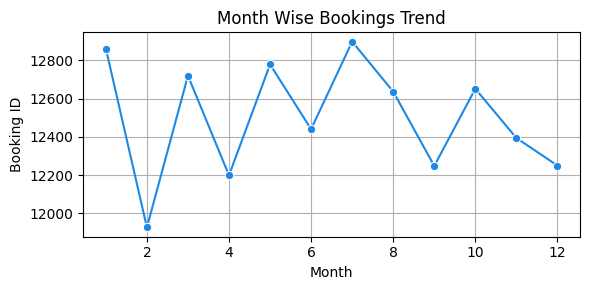

In [11]:
# Month wise ride bookings.

plt.figure(figsize=(6,3))
monthly_bookings = df.groupby('Month')['Booking ID'].count().reset_index()

sns.lineplot(data=monthly_bookings, x='Month', y='Booking ID', marker='o',color = '#1E88E5')
plt.title('Month Wise Bookings Trend')
plt.grid(True)
plt.tight_layout()
plt.show()



#### Insights
1. January recorded one of the highest numbers of bookings, indicating strong demand at the beginning of the year.
2. July had the highest booking volume, making it the peak month for ride bookings.
3. February recorded the lowest number of bookings among all months.
4. Booking volumes fluctuated throughout the year, with no consistent upward or downward trend.
5. After reaching a peak in July, bookings declined in September before showing a slight recovery in October.

### Weekends VS Weekdays Analysis

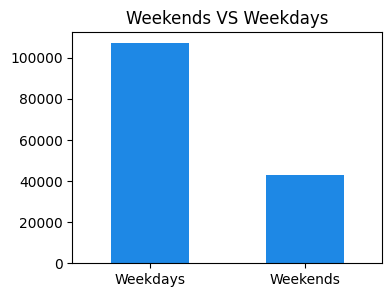

In [12]:
plt.figure(figsize=(4,3))
# sns.countplot(x = 'Weekends', data=df, color='#1E88E5')
df['Weekends'].value_counts().plot(kind = 'bar',  color='#1E88E5')
plt.plot
plt.title('Weekends VS Weekdays')
plt.xticks(ticks=[0, 1], labels=['Weekdays', 'Weekends'], rotation=0)
plt.xlabel('')
plt.show()

#### Insights
1. Approximately 40% of all ride bookings occur during weekends (Saturday and Sunday), indicating significantly higher customer demand compared to weekdays

### Top 10 Pickup and Drop locations

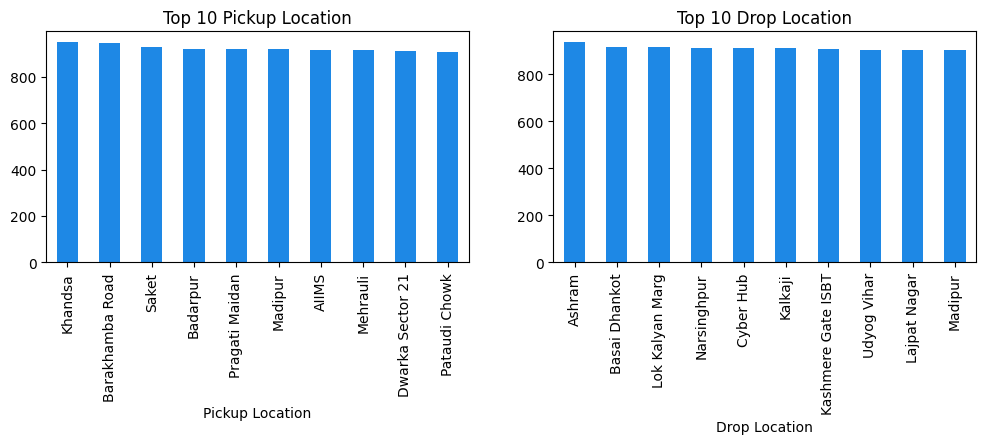

In [13]:
plt.figure(figsize=(12,3))
plt.subplot(1,2,1)
df['Pickup Location'].value_counts().head(10).plot(kind = 'bar', color='#1E88E5')
plt.title("Top 10 Pickup Location")
plt.subplot(1,2,2)
df['Drop Location'].value_counts().head(10).plot(kind = 'bar', color='#1E88E5')
plt.title("Top 10 Drop Location")
plt.show()

### Revenue Analysis

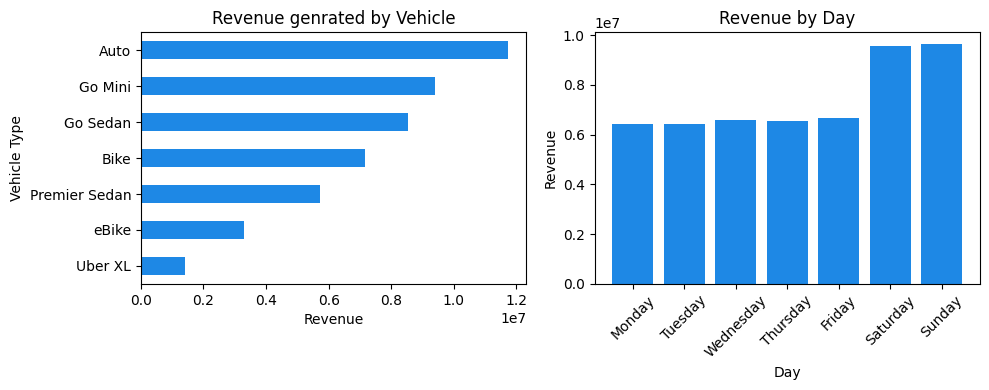

In [14]:
# Vehicles that genrate maximum revenue

completed = df[df['Booking Status']=='Completed']

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
completed.groupby('Vehicle Type')['Booking Value'].sum().sort_values().plot(kind='barh', color='#1E88E5')
plt.xlabel('Revenue')
plt.title('Revenue genrated by Vehicle')


# Revenue by day
plt.subplot(1,2,2)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day = df.groupby('DayofWeek')['Booking Value'].sum()
day = day.reindex(day_order)
plt.bar(day.index, day.values, color='#1E88E5')
plt.title('Revenue by Day')
plt.xlabel('Day')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


#### Insights
1. Auto is the highest revenue-generating vehicle type, contributing 24.8% of the total revenue. This indicates that Auto rides are the most popular and play a significant role in the company's overall revenue.
 
2. Uber XL contributes only 2% of total revenue, making it the lowest-performing vehicle category. This may indicate lower customer demand or limited availability.
 
3. Although weekends account for only 2 out of 7 days, they contribute approximately 37% of the total weekly revenue. This suggests significantly higher customer demand on Saturdays and Sundays.

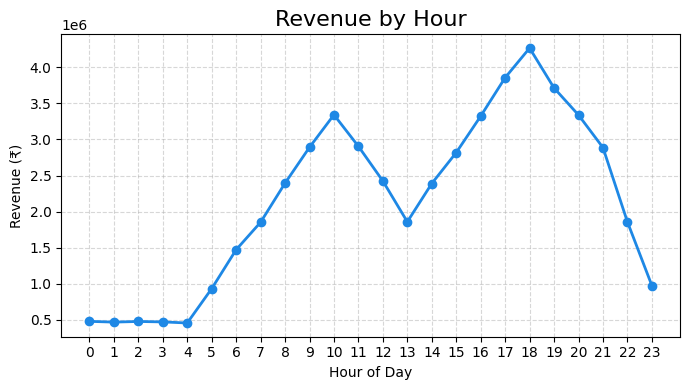

In [15]:
# Revenue by Hours

revenue_hours = df.groupby('Hour')['Booking Value'].sum()

plt.figure(figsize=(7,4))
plt.plot(revenue_hours.index, revenue_hours.values, linewidth = 2, marker = 'o', color='#1E88E5')

plt.title('Revenue by Hour', fontsize=16)
plt.xlabel('Hour of Day')
plt.ylabel('Revenue (₹)')
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

#### Insights
1. Revenue reaches its highest level at 6 PM (18:00), making it the most profitable hour of the day
2. Revenue rises sharply between 8 AM and 10 AM, with a local peak around 10 AM.
3. Revenue remains consistently low between 12 AM and 4 AM.
4. After a dip around 1 PM, revenue gradually increases from 2 PM onward before reaching the evening peak.
5. Revenue decreases steadily after 6 PM, with a noticeable drop after 10 PM.

In [16]:
Avg_fare = df.groupby('Vehicle Type')['Booking Value'].mean().sort_values()
print(f'Average Fare 💰: {Avg_fare}')

Average Fare 💰: Vehicle Type
Uber XL          501.816749
eBike            503.897090
Auto             506.725241
Go Mini          507.684934
Premier Sedan    509.568169
Bike             510.200299
Go Sedan         511.503385
Name: Booking Value, dtype: float64


### Vechicle Prefrences

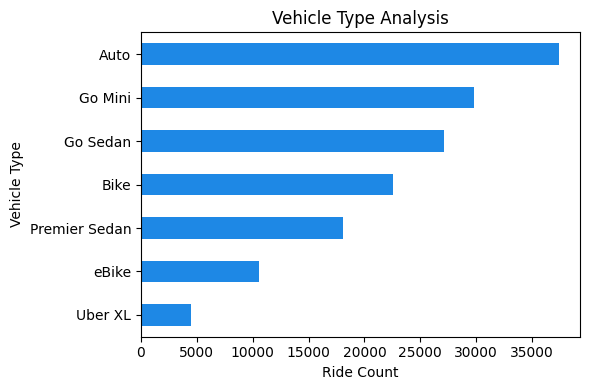

In [17]:
# Vehicle Type analysis
# Let see which vehical is most prefered by peoples

plt.figure(figsize=(6,4))

df['Vehicle Type'].value_counts().sort_values().plot(kind = 'barh', color='#1E88E5')
plt.title('Vehicle Type Analysis')
plt.xlabel('Ride Count')
plt.tight_layout()
plt.show()

#### Insights
1. Auto, Go Mini, and Go Sedan are the three most preferred vehicle types among customers, indicating consistently high demand. These vehicle categories contribute significantly to overall bookings and revenue

#### Recommendation
To maximize revenue, the company should prioritize these vehicle categories by ensuring adequate driver availability, especially during peak hours and weekends. Additionally, customer complaints, ride cancellations, and operational issues related to these vehicle types should be addressed promptly to improve customer satisfaction and encourage repeat bookings.

### Booking Status Analysis

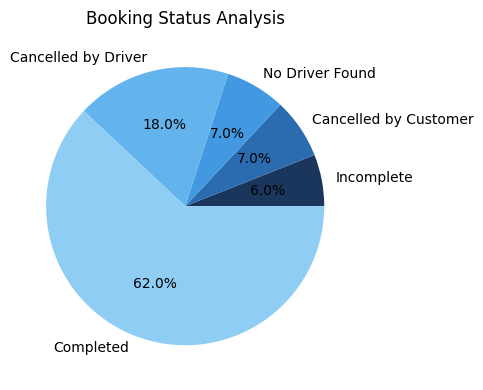

In [18]:
# Booking Status Analysis
plt.figure(figsize=(6,4))
blue_palette = ['#1A365D', '#2B6CB0', '#4299E1', '#63B3ED', '#90CDF4']
df['Booking Status'].value_counts().sort_values().plot(kind = 'pie', colors = blue_palette, autopct='%1.1f%%')
plt.title('Booking Status Analysis')
plt.tight_layout()
plt.show()

#### Insights
1. 62% of bookings were successfully completed, while the remaining 38% were either cancelled, not fulfilled due to driver unavailability, or marked as incomplete.
2. 18% of all bookings were cancelled by drivers, making it the largest reason for unsuccessful bookings.
3. 7% of bookings were cancelled by customers and also 7% of bookings could not be completed because no driver was available.

#### Payment Method Analysis

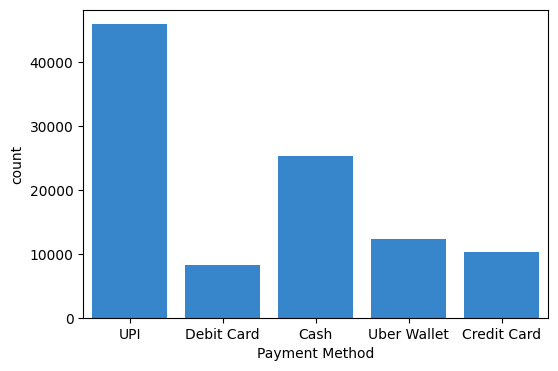

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='Payment Method', data=df, color='#1E88E5')
plt.show()

#### Insights

1. UPI is the most preferred payment method, accounting for approximately 45% of all transactions. This indicates a strong customer preference for fast and convenient digital payments.
2. Debit Card, Credit Card, and Uber Wallet collectively account for approximately 30% of all transactions, making them the second most preferred payment options after UPI.
3. Approximately 24% of transactions are completed using cash, indicating that a significant portion of customers still prefer traditional payment methods.

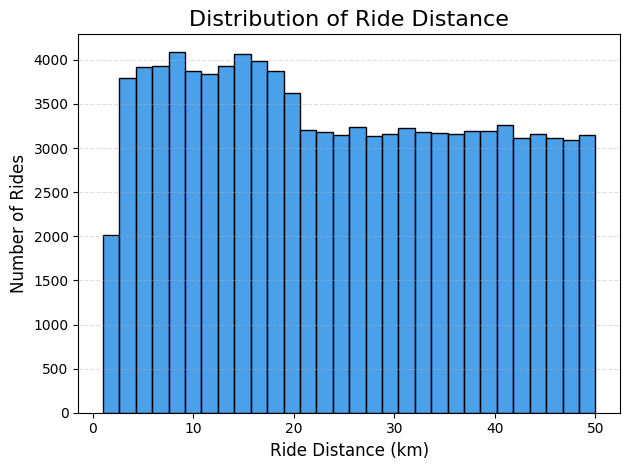

In [20]:
sns.histplot(
    data=df,
    x='Ride Distance',
    bins=30,
    color='#1E88E5',
    edgecolor='black',
    alpha=0.8
)

plt.title('Distribution of Ride Distance', fontsize=16)
plt.xlabel('Ride Distance (km)', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

#### Ride Distance VS Booking Value

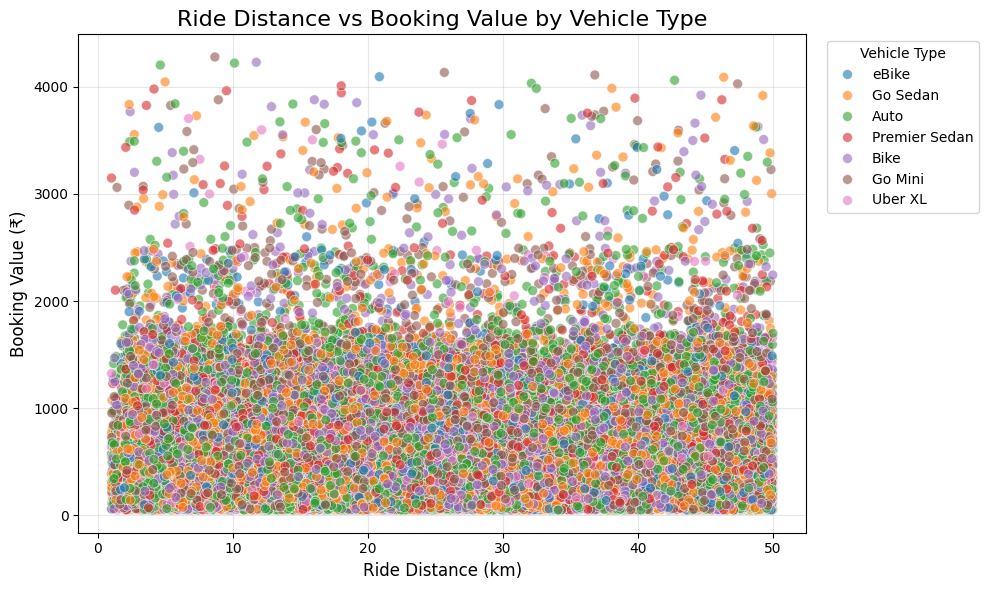

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Ride Distance',
    y='Booking Value',
    hue='Vehicle Type',      # Creates legend by vehicle type
    alpha=0.6,
    s=50
)

plt.title('Ride Distance vs Booking Value by Vehicle Type', fontsize=16)
plt.xlabel('Ride Distance (km)', fontsize=12)
plt.ylabel('Booking Value (₹)', fontsize=12)

plt.legend(title='Vehicle Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()